# Evaluación Avanzada de Clasificación de Textos Financieros
Este notebook se enfoca en métricas de robustez y análisis detallado para evaluar modelos de clasificación en contextos de datos financieros desbalanceados.

### Objetivos:
1. **F1-Score**: Evaluación profunda frente al desbalance de clases.
2. **Matriz de Confusión**: Análisis de ambigüedades en textos cortos.
3. **Precision vs Recall**: Optimización según el impacto del negocio.
4. **Validación Cruzada**: Medición de estabilidad y desviación estándar.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score, 
    f1_score, precision_score, recall_score, precision_recall_curve
)
from sklearn.preprocessing import LabelEncoder
import unicodedata
import re
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")


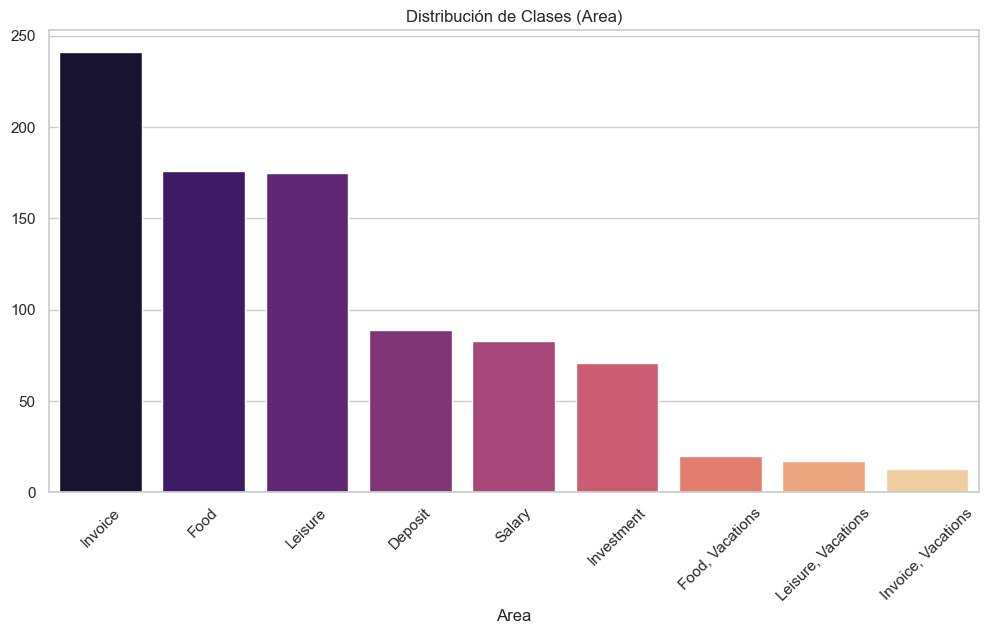

Número total de registros: 885
Clase mayoritaria (Invoice): 241 registros
Clase minoritaria (Invoice, Vacations): 13 registros


In [ ]:
# Carga de datos
data_path = '../data/raw/db_orig.csv'
data_path = '../data/raw/db_modified_descriptions.csv'
df = pd.read_csv(data_path)

# Visualización del desbalance de clases
plt.figure(figsize=(12, 6))
class_counts = df['Area'].value_counts()
sns.barplot(x=class_counts.index, y=class_counts.values, palette='magma')
plt.title('Distribución de Clases (Area)')
plt.xticks(rotation=45)
plt.show()

print(f"Número total de registros: {len(df)}")
print(f"Clase mayoritaria ({class_counts.index[0]}): {class_counts.values[0]} registros")
print(f"Clase minoritaria ({class_counts.index[-1]}): {class_counts.values[-1]} registros")


In [4]:
def preprocess_text(text):
    if not isinstance(text, str): return ""
    text = text.lower()
    text = ''.join(c for c in unicodedata.normalize('NFD', text) if unicodedata.category(c) != 'Mn')
    text = re.sub(r'[^a-z0-9\s]', '', text)
    return text.strip()

df['clean_text'] = df['Description'].apply(preprocess_text)

le = LabelEncoder()
y = le.fit_transform(df['Area'])
X = df['clean_text']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


## 1. Más allá del Accuracy: F1-Score
En datos desbalanceados, un modelo "perezoso" que siempre prediga la clase mayoritaria puede tener un Accuracy alto pero un F1-Score muy bajo para las clases críticas.


In [5]:
tfidf = TfidfVectorizer(ngram_range=(1, 2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

model = LogisticRegression(class_weight='balanced') # Usamos pesos para mitigar desbalance
model.fit(X_train_tfidf, y_train)
y_pred = model.predict(X_test_tfidf)

acc = accuracy_score(y_test, y_pred)
f1_macro = f1_score(y_test, y_pred, average='macro')
f1_weighted = f1_score(y_test, y_pred, average='weighted')

print(f"Accuracy: {acc:.4f}")
print(f"F1-Score (Macro - trata todas las clases igual): {f1_macro:.4f}")
print(f"F1-Score (Weighted - proporcional al tamaño de la clase): {f1_weighted:.4f}")

print("\nReporte Detallado:")
print(classification_report(y_test, y_pred, target_names=le.classes_))


Accuracy: 1.0000
F1-Score (Macro - trata todas las clases igual): 1.0000
F1-Score (Weighted - proporcional al tamaño de la clase): 1.0000

Reporte Detallado:
                    precision    recall  f1-score   support

           Deposit       1.00      1.00      1.00        18
              Food       1.00      1.00      1.00        35
   Food, Vacations       1.00      1.00      1.00         4
        Investment       1.00      1.00      1.00        14
           Invoice       1.00      1.00      1.00        48
Invoice, Vacations       1.00      1.00      1.00         3
           Leisure       1.00      1.00      1.00        35
Leisure, Vacations       1.00      1.00      1.00         3
            Salary       1.00      1.00      1.00        17

          accuracy                           1.00       177
         macro avg       1.00      1.00      1.00       177
      weighted avg       1.00      1.00      1.00       177



## 2. Matriz de Confusión para Depuración
Permite identificar dónde el modelo se confunde (ej. palabras ambiguas en descripciones cortas).


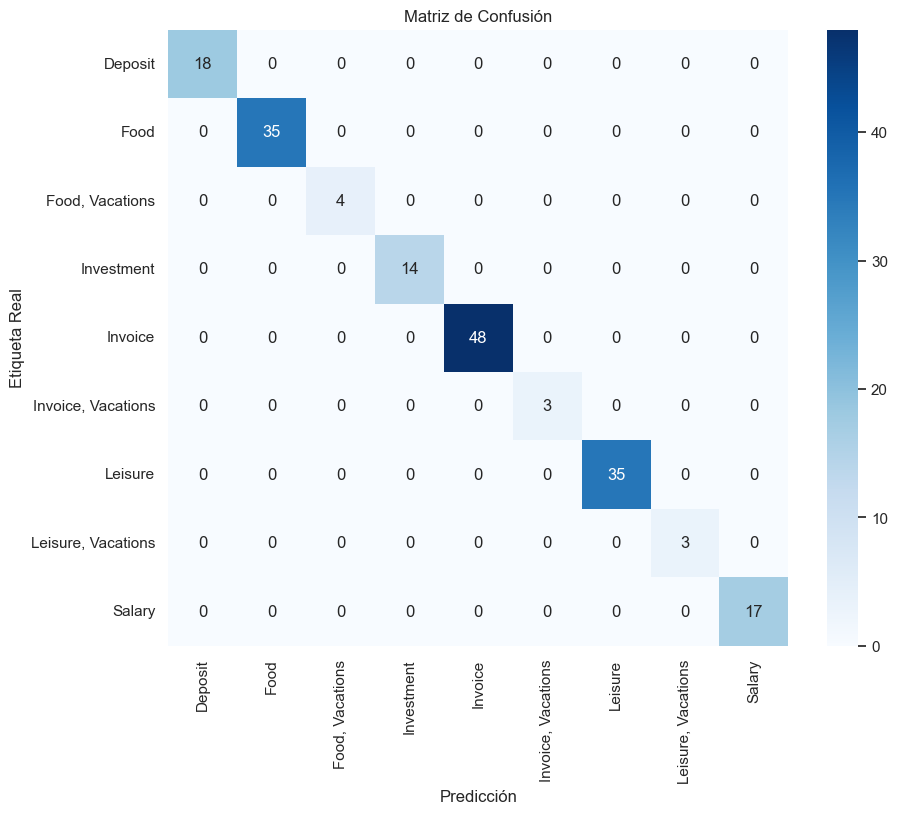

In [6]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Matriz de Confusión')
plt.ylabel('Etiqueta Real')
plt.xlabel('Predicción')
plt.show()


## 3. Precision vs Recall según el Caso de Uso
- **Optimizar Precisión**: Para evitar falsos positivos (ej. no clasificar un gasto manual como ingreso).
- **Optimizar Recall**: Para no perder ningún registro de una clase (ej. detectar todos los gastos deducibles).


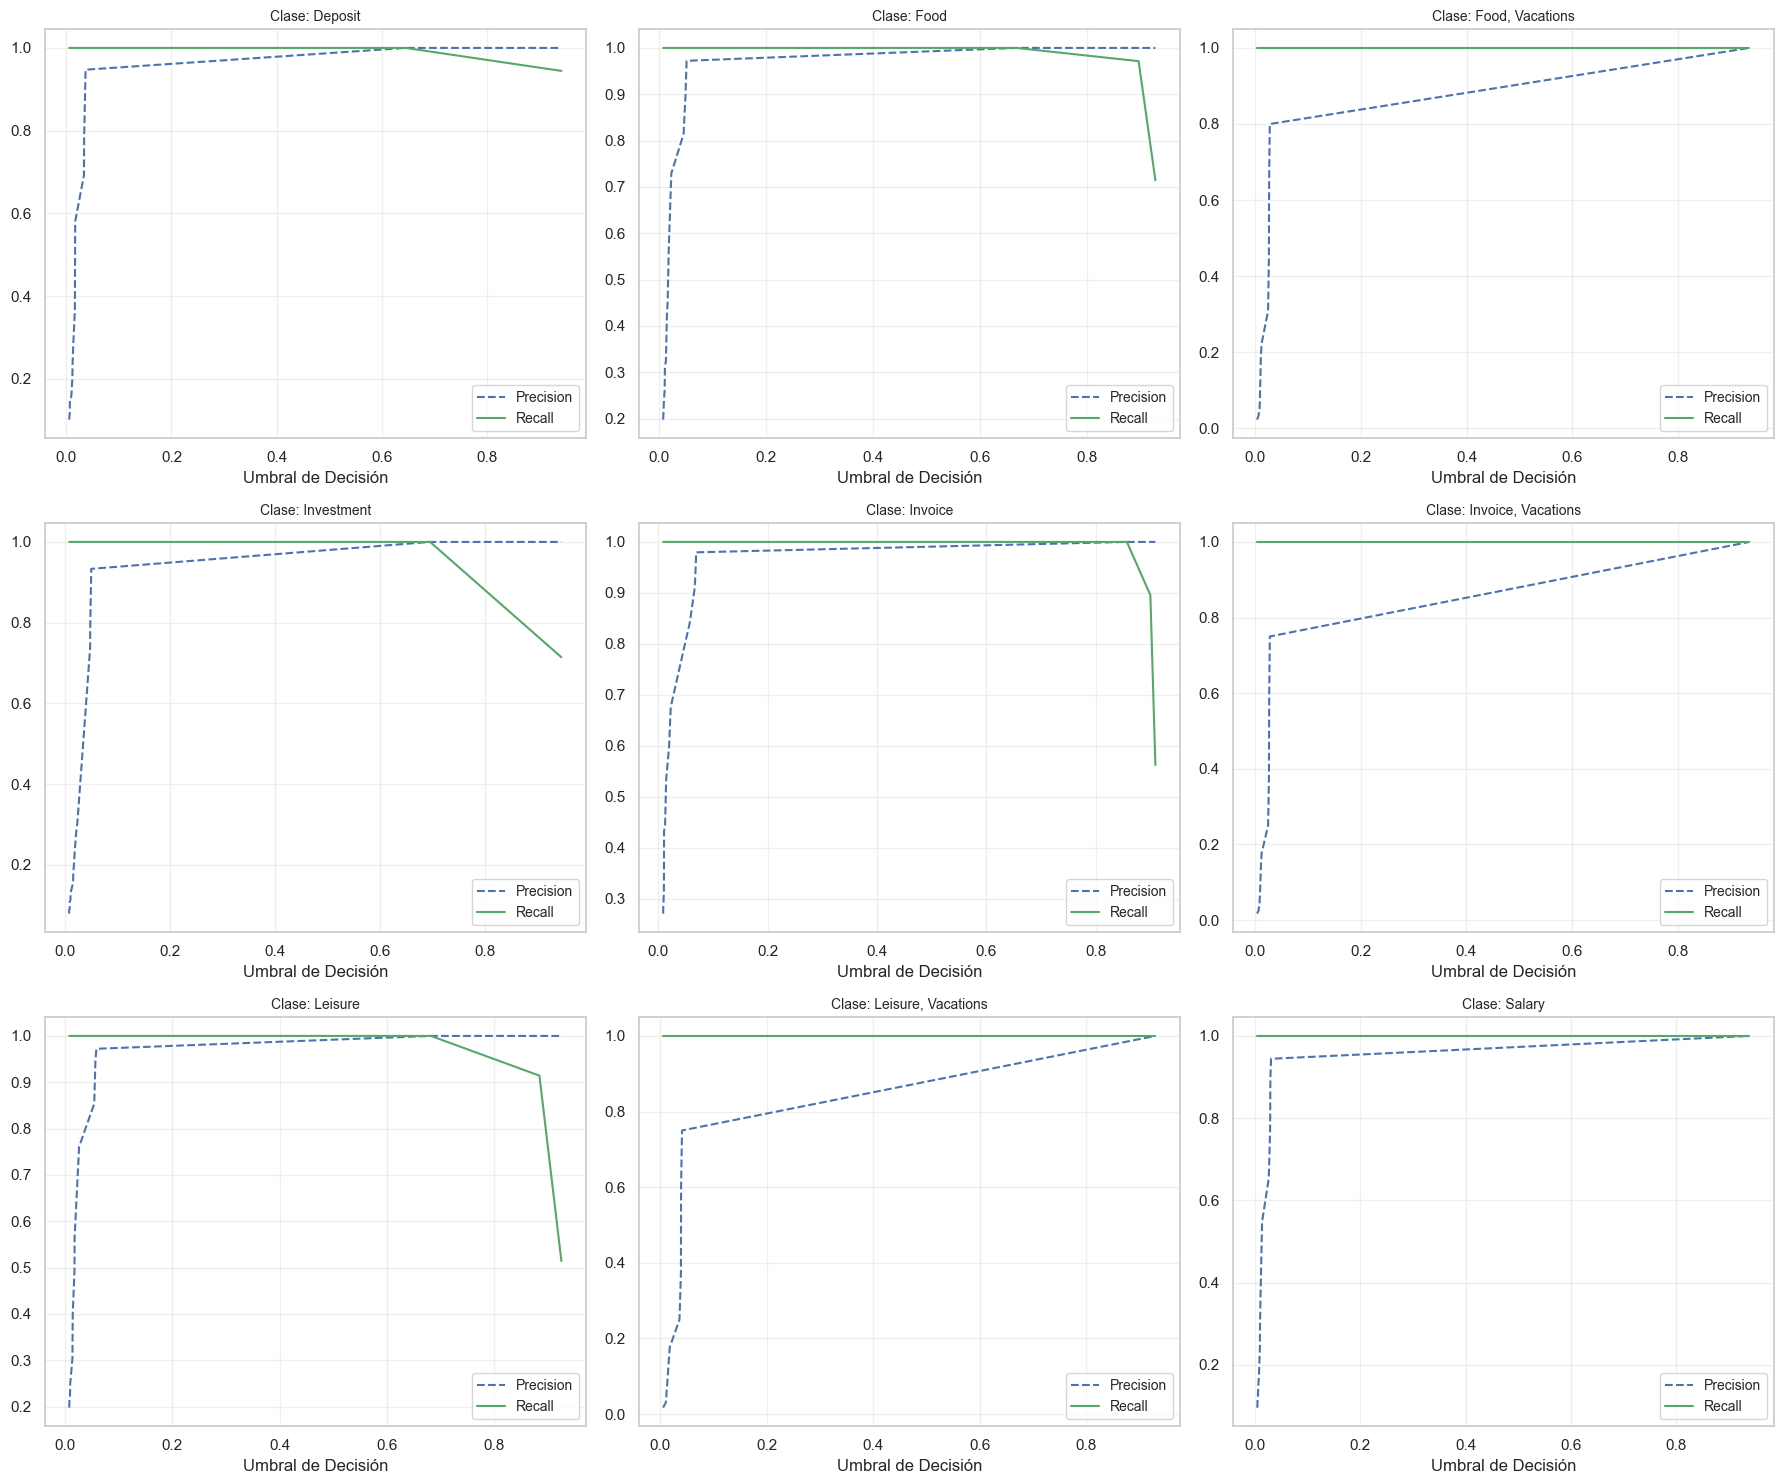

In [9]:
# 1. Creamos la figura y la matriz de subplots (3 filas, 3 columnas)
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(18, 15))

# 2. Aplanamos la matriz de axes para iterar más fácilmente (de 3x2 a un array de 9)
axes = axes.flatten()

for target_class in range(9):
    # Seleccionamos el eje (subplot) actual
    ax = axes[target_class]
    
    y_test_binary = (y_test == target_class).astype(int)
    y_scores = model.predict_proba(X_test_tfidf)[:, target_class]

    precisions, recalls, thresholds = precision_recall_curve(y_test_binary, y_scores)

    # Graficamos en 'ax' en lugar de 'plt'
    ax.plot(thresholds, precisions[:-1], "b--", label="Precision")
    ax.plot(thresholds, recalls[:-1], "g-", label="Recall")
    
    # Configuramos títulos y etiquetas usando métodos 'set_'
    ax.set_title(f"Clase: {le.classes_[target_class]}", fontsize=10)
    ax.set_xlabel("Umbral de Decisión")
    ax.legend(loc="best", fontsize='small')
    ax.grid(True, alpha=0.3)

# 3. Ajustamos el espaciado para que no se solapen los títulos
plt.tight_layout()
plt.show()


## 4. Estabilidad y Validación Cruzada
Evaluamos la consistencia del modelo mediante 5-Fold Cross Validation.


F1-Macro medio: 1.0000 (+/- 0.0000)
Accuracy medio: 1.0000 (+/- 0.0000)


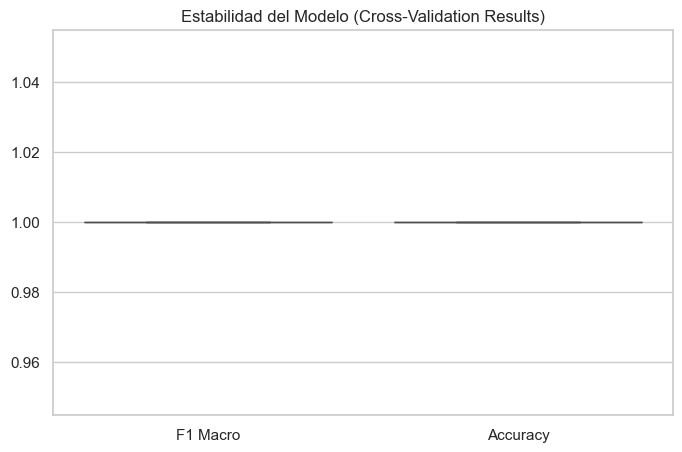

In [8]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
X_tfidf_full = tfidf.fit_transform(X)

cv_f1_macro = cross_val_score(model, X_tfidf_full, y, cv=skf, scoring='f1_macro')
cv_acc = cross_val_score(model, X_tfidf_full, y, cv=skf, scoring='accuracy')

print(f"F1-Macro medio: {cv_f1_macro.mean():.4f} (+/- {cv_f1_macro.std():.4f})")
print(f"Accuracy medio: {cv_acc.mean():.4f} (+/- {cv_acc.std():.4f})")

plt.figure(figsize=(8, 5))
sns.boxplot(data=[cv_f1_macro, cv_acc])
plt.xticks([0, 1], ['F1 Macro', 'Accuracy'])
plt.title('Estabilidad del Modelo (Cross-Validation Results)')
plt.show()


## Conclusiones
1. El **F1-Score** nos da una visión honesta del desempeño en clases minoritarias.
2. La **Matriz de Confusión** revela ambigüedades semánticas.
3. La **Validación Cruzada** confirma si el modelo es robusto o si está sobreajustado a ciertos patrones.
